Fast Food Marketing Campaign Analysis

The aim of this project is to evaluate marketing campaigns and determine which ones convert the most customers. We have a database containing the characteristics and results of 3 marketing campaigns to promote a new item in the menu of a fast-food chain. Given that there are 3 campaigns to analyze, the correct term is multivariate testing, where we compare each campaign with the others. Here the methodology of our project:

1.   perform an Exploratory Data Analysis whose objective is to ensure that groups 1, 2 and 3 are well balanced on the other features
2.   Perform the multivariate testing
3.   Study confounding features, some features may affect the sales, if not controlled, they can lead to biased results, making it seem like the promotion caused the outcome when it was actually the confounder.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols
import os
import warnings

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WA_Marketing-Campaign.csv to WA_Marketing-Campaign.csv


1. Preprocessing

In [ ]:
data = pd.read_csv('WA_Marketing-Campaign.csv')
data

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


The new item is introduced at locations in several randomly selected markets (MarketID). A different promotion (one of the 3 marketing campaigns) is used at each location (LocationID), and the weekly sales of the new item are recorded for the first four weeks. Each market is defined by its ID, Size, Location and Age and each Promotion by its sales at each week.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


*   In our data, MarketID, LocationID, Promotion and Week are numerical features but in a data analysis they are more categorial features, so we'll transform them into categorial features.

*   AgeOfStore is numerical, it will be more relevant to transform it in categorial by recoding. Depending of the age of the store, we will have 'new', 'middle', 'old' and it will be interesting to analyze the interaction with sales feature. We suggest a division that prioritizes balanced observations. Then we'll use quantile cut.



In [ ]:
#Changing features dtypes
data['MarketID'] = data['MarketID'].astype('category')
data['LocationID'] = data['LocationID'].astype('category')
data['Promotion'] = data['Promotion'] .astype('category')
data['week'] = data['week'] .astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   MarketID          548 non-null    category
 1   MarketSize        548 non-null    object  
 2   LocationID        548 non-null    category
 3   AgeOfStore        548 non-null    int64   
 4   Promotion         548 non-null    category
 5   week              548 non-null    category
 6   SalesInThousands  548 non-null    float64 
dtypes: category(4), float64(1), int64(1), object(1)
memory usage: 21.5+ KB


In [ ]:
#Recoding AgeOfStore

#Showing feature modalities
Age_modalities = sorted(data['AgeOfStore'].unique())
print("Modalities of AgeofStore:", Age_modalities)

#Recoding by creating a new feature apart with qcut
data[ "store_age"]=pd.qcut(data['AgeOfStore'] , q=3 , labels = ['new' , 'middle' , 'old'])
data[["AgeOfStore", "store_age"]]

Modalities of AgeofStore: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(27), np.int64(28)]


,AgeOfStore,store_age
0,4,new
1,4,new
2,4,new
3,4,new
4,5,new
...,...,...
543,2,new
544,14,old
545,14,old
546,14,old


In [ ]:
data.isnull().sum()

,0
MarketID,0
MarketSize,0
LocationID,0
AgeOfStore,0
Promotion,0
week,0
SalesInThousands,0
store_age,0


There is no missing values in the data. Let's go to EDA

2. Exploratory Data Analysis

Here our Promotion is our target feature and SalesInThousands our metric. So the analysis must be oriented to them.
We are going to do firstly an univariate for Promotion and Sales.  Then bivariate analysis (interaction between 2 features), we will check if Promotion is represented in a balanced way for other categarical features (MarketSize, store_age, week) and for the numerical AgeOfStore.

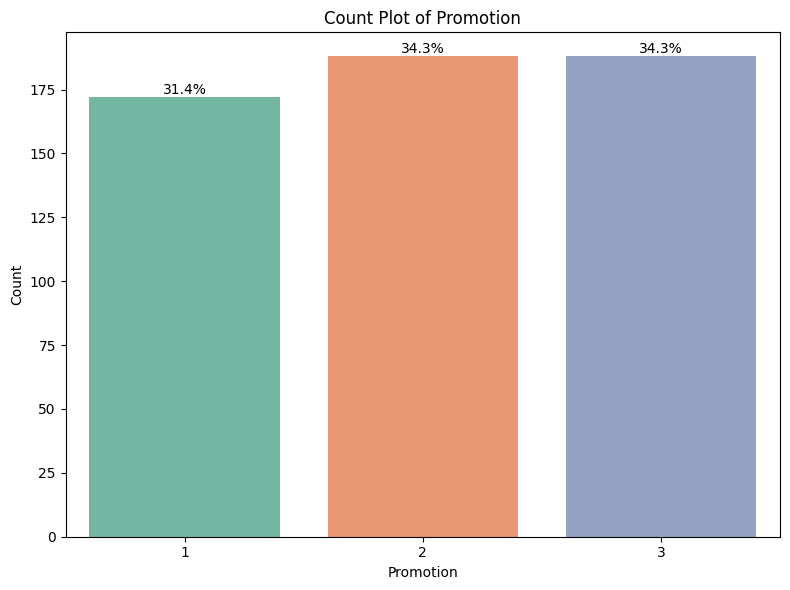

In [ ]:
#Count plots of Promotion with purcentage annotations

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=data, x='Promotion', hue='Promotion', palette='Set2', legend=False)
plt.title(f'Count Plot of Promotion')
plt.xlabel('Promotion')
plt.ylabel('Count')

# Annotate each bar with percentage
total = len(data)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, color='black')
plt.tight_layout()
plt.show()

From the above plot , we see the dataset is quite balanced between the 3 promotion plans .

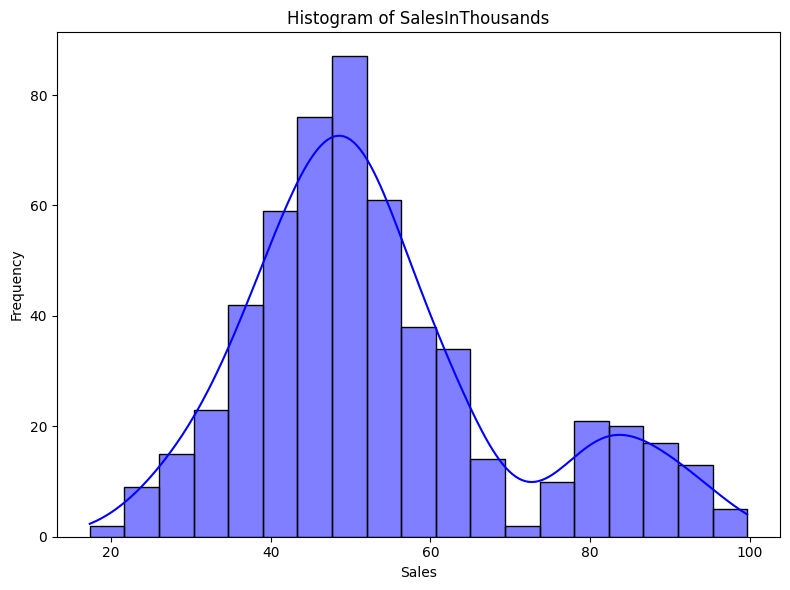

In [ ]:
#Histogram for sales
plt.figure(figsize=(8,6))
sns.histplot(data['SalesInThousands'], kde= True, color='blue')
plt.title(f'Histogram of SalesInThousands')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

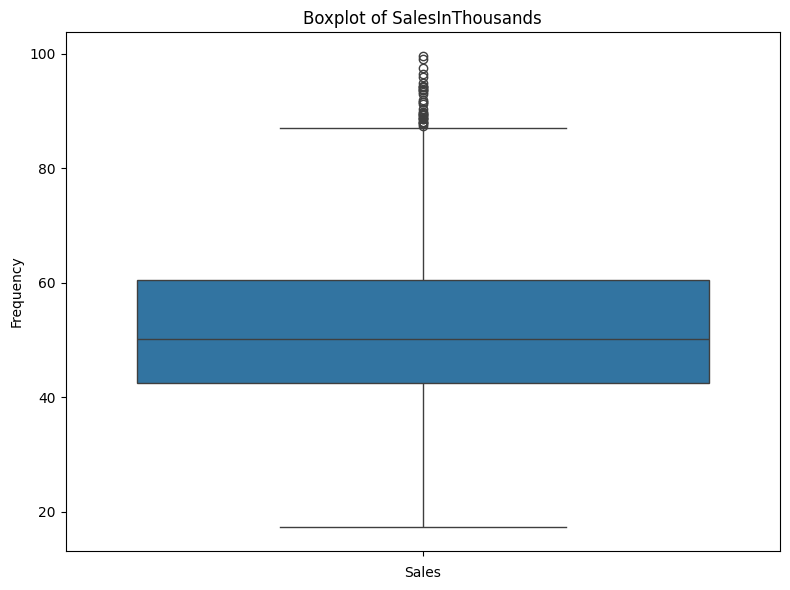

In [ ]:
#boxplot
plt.figure(figsize=(8,6))
sns.boxplot(data['SalesInThousands'])
plt.title(f'Boxplot of SalesInThousands')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.subplots_adjust()
plt.show()

We can see that the SalesInThousands has a mean of 53 thousand and a median around 50 thousand dollars. The data is not distributed normally. We have dispersion in the right and up to 15% of sales are higher than 75 thousand dollars.


=== Distribution of MarketSize by Promotion
Promotion    1    2    3
MarketSize              
Large       56   64   48
Medium      96  108  116
Small       20   16   24
Promotion           1          2          3
MarketSize                                 
Large       32.558140  34.042553  25.531915
Medium      55.813953  57.446809  61.702128
Small       11.627907   8.510638  12.765957


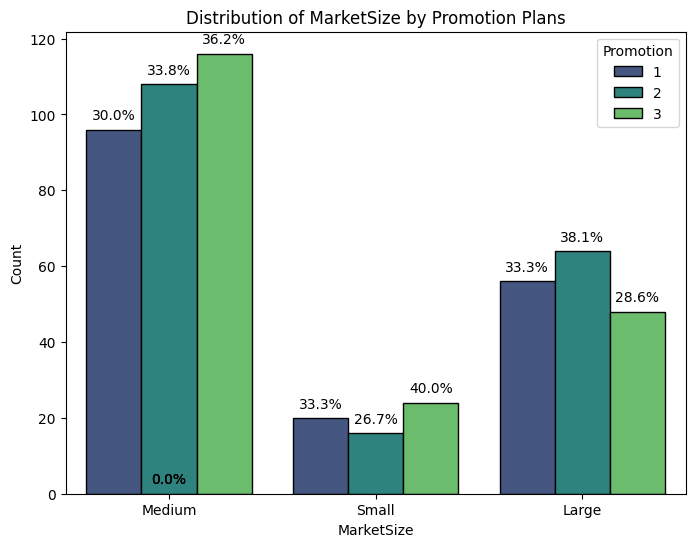


=== Distribution of store_age by Promotion
Promotion   1   2   3
store_age            
new        72  80  68
middle     44  64  60
old        56  44  60
Promotion          1          2          3
store_age                                 
new        41.860465  42.553191  36.170213
middle     25.581395  34.042553  31.914894
old        32.558140  23.404255  31.914894


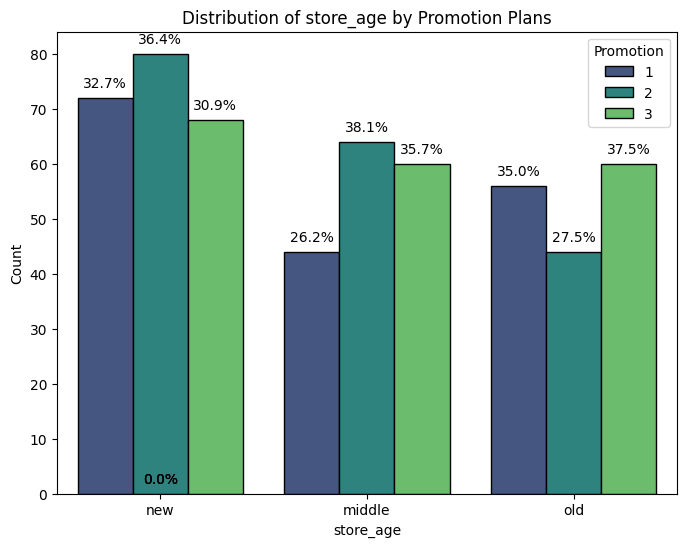


=== Distribution of week by Promotion
Promotion   1   2   3
week                 
1          43  47  47
2          43  47  47
3          43  47  47
4          43  47  47
Promotion     1     2     3
week                       
1          25.0  25.0  25.0
2          25.0  25.0  25.0
3          25.0  25.0  25.0
4          25.0  25.0  25.0


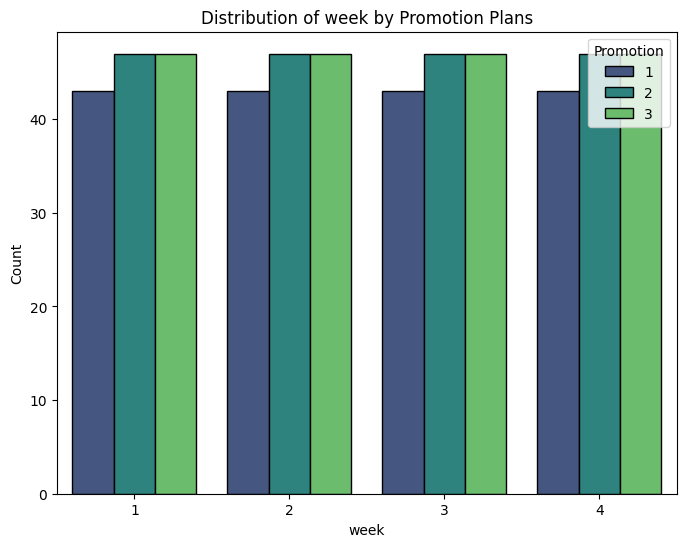

In [ ]:
#Distribution of Promotion by other categorical features
categorical_features = ['MarketSize', 'store_age', 'week']

for feature in categorical_features:
    print(f"\n=== Distribution of {feature} by Promotion")
    contingency_table = pd.crosstab(data[feature], data['Promotion'])
    print(contingency_table)

    # Visualize the distribution
    print(pd.crosstab(data[feature], data['Promotion'], normalize='columns') * 100)

    # Visualization
    plt.figure(figsize=(8, 6))
    ax= sns.countplot(data=data, x=feature, hue='Promotion', palette="viridis",
    edgecolor="black", linewidth=1)
    plt.title(f"Distribution of {feature} by Promotion Plans")
    plt.xlabel(f'{feature}')
    plt.ylabel('Count')

    # Add percentage annotations
    counts = data.groupby([feature, 'Promotion'], observed=True).size().reset_index(name='count')
    total_counts = data[feature].value_counts()
    category_order = [t.get_text() for t in ax.get_xticklabels()]
    for p in ax.patches:
        height = p.get_height()
        x_pos = p.get_x() + p.get_width() / 2.
        cat_idx = int(round(x_pos))
        if cat_idx < 0 or cat_idx >= len(category_order):
            continue
        category = category_order[cat_idx]
        total = total_counts.get(category, 0)
        if total > 0:
            percent = height / total * 100
            ax.annotate(f'{percent:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        xytext=(0, 5),
                        textcoords='offset points')
    plt.show()

We can see from the above plots that Promotion is distributed in a balanced way accross weeks, but it is not the case with MarketSize and store_age. We can confirm that with chi2 statistical test.

In [ ]:
# Verification with statistical chi2 test

for feature in categorical_features:
  #Contengency table
  contingency_table = pd.crosstab(data[feature], data['Promotion'])
  # Chi2 Test
  chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

  print("Chi2 test to check balance of 'feature' between Promotion groups:")
  print(f"Chi2 Statistic = {chi2:.2f}, P-value = {p_value:.4f}")

  if p_value < 0.05:
      print(f"The {feature} feature is unbalanced between Promotion groups.")
  else:
      print(f"The {feature} feature is balanced between Promotion groups.")

Chi2 test to check balance of 'feature' between Promotion groups:
Chi2 Statistic = 4.75, P-value = 0.3135
The MarketSize feature is balanced between Promotion groups.
Chi2 test to check balance of 'feature' between Promotion groups:
Chi2 Statistic = 6.68, P-value = 0.1535
The store_age feature is balanced between Promotion groups.
Chi2 test to check balance of 'feature' between Promotion groups:
Chi2 Statistic = 0.00, P-value = 1.0000
The week feature is balanced between Promotion groups.


So Promotion is balanced accros other categorical features. We can then perform the multivariate testing

3. Mutivariate testing

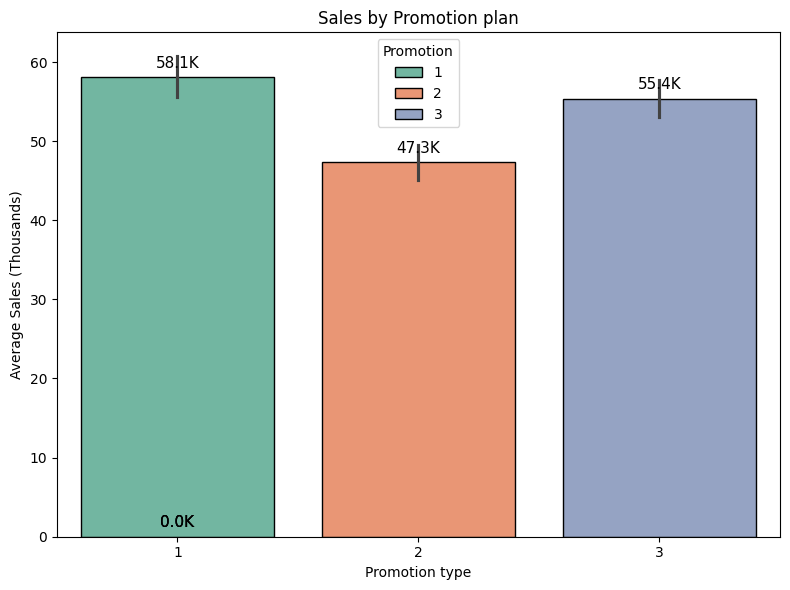

In [ ]:
#Visualize relationship between Promotion and Sales
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=data,
    y="SalesInThousands",
    x="Promotion",
    estimator='mean',
    hue="Promotion",
    palette="Set2",
    edgecolor="black",
    linewidth=1
)
plt.title('Sales by Promotion plan')
plt.xlabel('Promotion type')
plt.ylabel('Average Sales (Thousands)')
#Annotation
for p in ax.patches:
  ax.annotate(
        f'{p.get_height():.1f}K',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11
    )
plt.tight_layout()
plt.show()

Average sales made with promotion 1 is the highest, follwed by promotion 3 and then promotion 2. Visually the difference is not significative, so we'll need other test.

There are many test to check for significative relationship between a categorial feature and a numerical one. Here the categorial feature (Promotion) has more than 2 modalities and the numerical feature SalesInThousand in not normally distributed. So the suitable test is Kruskal-Wallis. The last condition is that that distributions of the groups of Promotion have the same shape with similar variability and skewness. We verify that firtsly visually with histograms and confirm with the Levene test.

<ipython-input-15-6a89f97b00d1>:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


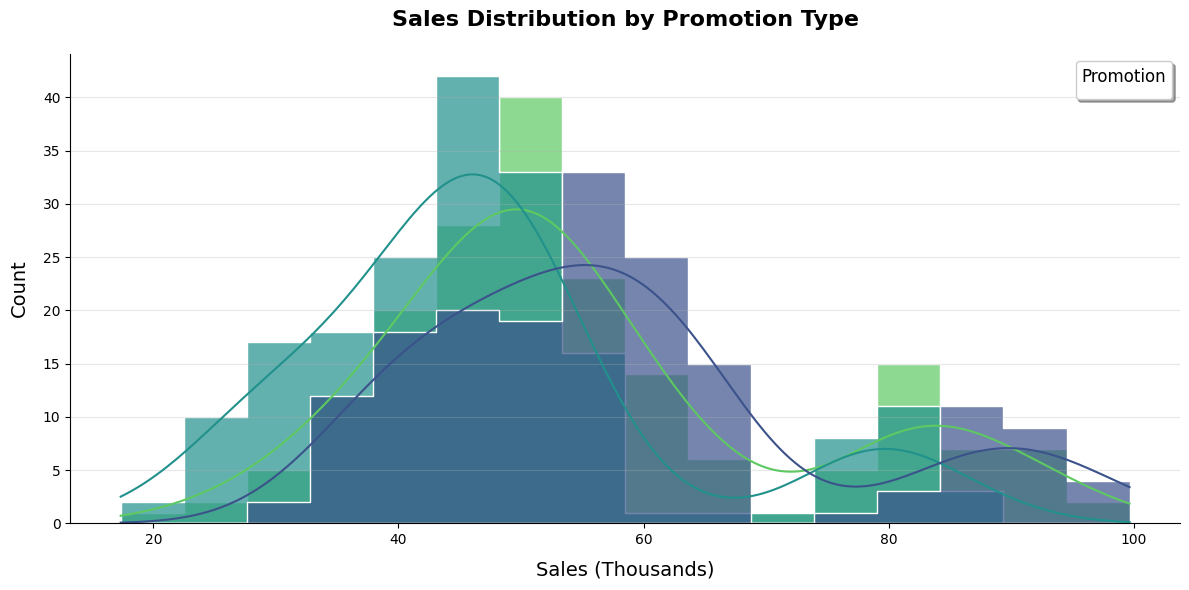

In [ ]:
plt.figure(figsize=(12, 6))
# Create the histogram with customizations
sns.histplot(
    data=data,
    x="SalesInThousands",
    hue="Promotion",
    palette="viridis",
    element="step",     # Clean stepped appearance
    kde=True,           # Add kernel density estimate
    alpha=0.7,          # Slight transparency
    multiple="layer",   # Overlay histograms
    edgecolor='white',  # White edges for separation
    linewidth=1,        # Edge line width
    binwidth=5          # Control bin size
)
plt.title('Sales Distribution by Promotion Type', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Sales (Thousands)', fontsize=14, labelpad=10)
plt.ylabel('Count', fontsize=14, labelpad=10)
plt.grid(axis='y', alpha=0.3)

plt.legend(
    title='Promotion',
    title_fontsize=12,
    fontsize=11,
    frameon=True,
    shadow=True
)
# Remove unnecessary spines
sns.despine()
plt.tight_layout()
plt.show()


We see from the graph that the 3 groups have a similar looking distribution , thrice of them skewed to the right. Let's confirm with Levene test.

In [ ]:
promotion1 = data.loc[data['Promotion']==1 , ['SalesInThousands']]
promotion2 = data.loc[data['Promotion']==2 , ['SalesInThousands']]
promotion3 = data.loc[data['Promotion']==3 , ['SalesInThousands']]
stats.levene(promotion1 , promotion2 , promotion3)

LeveneResult(statistic=array([1.26967875]), pvalue=array([0.28175146]))

pvalue= 0.28 > 0.05, so there is no group that has a significative variance, variance of groups are equal.

In [ ]:
#Kruskal-Wallis test
from scipy.stats import kruskal
stat, p_value = kruskal(promotion1, promotion2, promotion3)
print(f'Statistic H = {stat.item():.3f}')
print(f'P-value = {p_value.item():.4f}')

# Interpretation
if p_value < 0.05:
    print("There is a significative difference between groups.")
else:
    print("No significative difference between groups.")

Statistic H = 53.295
P-value = 0.0000
There is a significative difference between groups.


We have one of the groups has a different mean sales in thousands.

But the test statistic result gives us just a hint that there is difference between the 3 groups , what is the direction of this difference ( which promotion plan sell more) , which promotion made sales increase , in which subgroup each promotion masters , all of this we need to explore later.

We saw that average sales made with promotion 1 is the highest, follwed by promotion 3 and then promotion 2. Let's now check whether these differences are significant, two by two, by performing the Kolmogorov-Smirnov test, which is a non-parametric test comparing the cumulative distribution functions of two samples.

In [ ]:
#Promotion 1 vs Promotion 3
stat13 , p13 = stats.ks_2samp(promotion1, promotion3)
print((p13 < 0.05)[0])

True


There is a significant difference between sales resulted from promotion 1 and sales resulted from promotion 3 , from the graph of Average Sales by Promotion Plan we see that direction of difference is in the side of promotion 1.

In [ ]:
#Promotion 1 vs Promotion 2
stat12 , p12 = stats.ks_2samp(promotion1, promotion2)
print((p12 < 0.05)[0])

True


There is a significant difference between sales resulted from promotion 1 and sales resulted from promotion 2 , from the graph of Average Sales by Promotion Plan we see that direction of difference is in the side of promotion 1.

In [ ]:
#Promotion 2 vs Promotion 3
stat23 , p23 = stats.ks_2samp(promotion2, promotion3)
print((p23 < 0.05)[0])

True


There is a significant difference between sales resulted from promotion 1 and sales resulted from promotion 2 , from the graph of Average Sales by Promotion Plan we see that direction of difference is in the side of promotion 1. We can conclude that there is a significant difference between sales across different pormotion plans , the best one for sales is promotion 1 followed by promotion 3 and the least effective plan is promotion 2.

4. Studying confounding features

A confounding feature in our case is an external factor that correlates with the Promotion plans and directly affects the sales.
If not controlled, confounders can lead to biased results, making it seem like the treatment caused the outcome when it was actually the confounder.
We should take into consideration , that if one of promotions was applied in a week , market size , or specific stores that already has significant different sales pattern than other weeks , market sizes and stores. For this sake, for each eventual confounding feature, we will check wether its influence the sales, and then we will treat these confounding features.

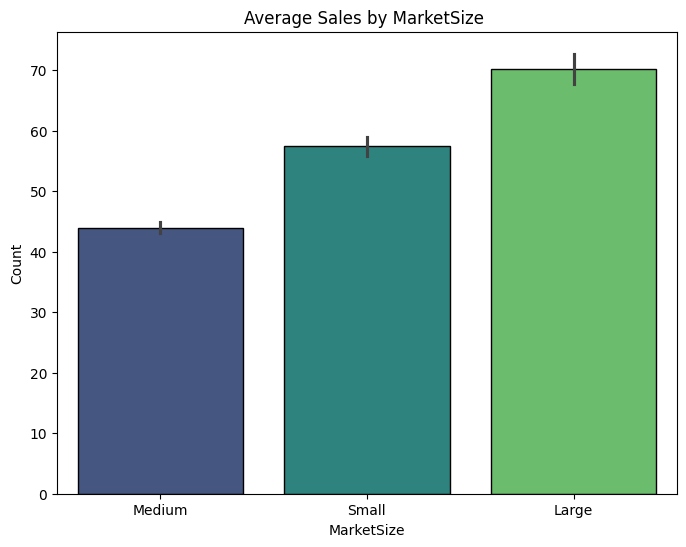

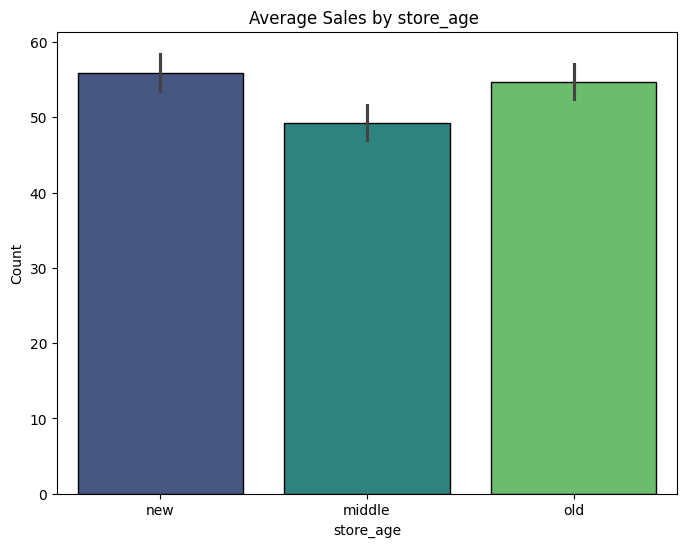

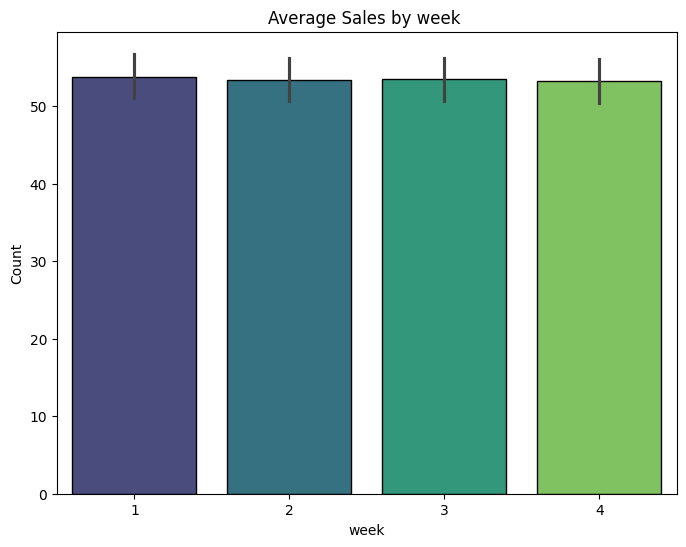

In [ ]:
#Distribution of eventual confounding features by Sales :
for feature in categorical_features:
    plt.figure(figsize=(8, 6))
    ax= sns.barplot(x=feature, y='SalesInThousands', hue= feature, data=data,
               estimator='mean', palette="viridis", edgecolor="black", legend= False, linewidth=1)
    ax.set_title(f"Average Sales by {feature} ")
    ax.set_xlabel(f'{feature}')
    ax.set_ylabel('Count')
    plt.show()

We can suggest that MarketSize and Store_age influence the sales but it is not the case with Week. We can confirm it with the presence of influence with Kruskal Wallis test.

In [ ]:
#MarketSize and Sales relationship
SmallMarket = data.loc[data['MarketSize']=='Small', ['SalesInThousands']]
MediumMarket = data.loc[data['MarketSize']=='Medium' , ['SalesInThousands']]
LargeMarket = data.loc[data['MarketSize']=='Large' , ['SalesInThousands']]
#Kruskal-Wallis test
stat, p_value = kruskal(SmallMarket, MediumMarket, LargeMarket)
print(f'Statistic H = {stat.item():.3f}')
print(f'P-value = {p_value.item():.4f}')

# Interpretation
if p_value < 0.05:
    print("There is a significative difference between groups.")
else:
    print("No significative difference between groups.")

Statistic H = 256.439
P-value = 0.0000
There is a significative difference between groups.


In [ ]:
#store_age and Sales relationship
newStore = data.loc[data['store_age']=='new', ['SalesInThousands']]
middleStore = data.loc[data['store_age']=='middle' , ['SalesInThousands']]
oldStore = data.loc[data['store_age']=='old' , ['SalesInThousands']]
#Kruskal-Wallis test
stat, p_value = kruskal(newStore, middleStore, oldStore)
print(f'Statistic H = {stat.item():.3f}')
print(f'P-value = {p_value.item():.4f}')

# Interpretation
if p_value < 0.05:
    print("There is a significative difference between groups.")
else:
    print("No significative difference between groups.")

Statistic H = 15.870
P-value = 0.0004
There is a significative difference between groups.


So, MarketSize and store_age are our confounding features. From now we have two options:
We need to control them to correct biaises and after we can determine the

*   stratify the analysis (compare Promotion plans separately by MarketSize and Store_age)
*   run an adjusted regression to control for this effect

The idea is to eliminate potential bias before interpreting the test
and determine which promotion plan that actually is better.
We will do a linear regression to control confounding features. The linear regression will adjust sales differences as if all promotions had been applied in markets of identical size and stores of the same age.

In [ ]:
# Encode categorical variables automatically with Patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf
model = smf.ols('SalesInThousands ~ C(Promotion) + C(MarketSize) + C(store_age)', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       SalesInThousands   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     137.0
Date:                Thu, 01 May 2025   Prob (F-statistic):          3.87e-105
Time:                        12:36:46   Log-Likelihood:                -2068.6
No. Observations:                 548   AIC:                             4151.
Df Residuals:                     541   BIC:                             4181.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 


1.   Model quality
R-squared= 0.603. This means that 60.3% of the variation in sales is explained by our variables Promotion, MarketSize, store_age. That's pretty decent.

*   F-statistic= 137.0 (p-value ≈ 0). The model is globally significant.


2.   Features effects
*   Promotion 2 has a coefficient = -10.28 and a p-value = 0.000, significant. Then Stores with promotion 2 sell on average $10,280 less than those with promotion 1 (the reference), all other things being equal.
*   Promotion 3 has a p-value = 0.540, not significant. This means that promotion 3 does not differ significantly from promotion 1 in terms of sales

*   Medium market has a coefficient = -26.47 and pvalue = 0.000, highly significant. In consequence, Stores in Medium market sell $26,470 less than those in Large market (reference).

*   Small market has a coefficient = -13.23 and pvalue= 0.0, significant. Sales of small markets are reduced by $13,230 compared with a “Large” market.

*   Middle age stores has a coefficient = -5.27 and pvalue < 0.001, significant.
These stores sell on average $5,270 less than New stores.

*   Old stores has a coeficient pvalue = 0.796, not significant. There is no real difference with New stores.


3.   Conclusions

Compare to Promotion 1, Promotion 2 is not good for sales: strong and significant negative effect.

Promotion 3 is neutral: it neither improves nor worsens sales compared with promotion 1.

Market and store age also have a strong influence on sales.

In [ ]:
# Promotion-adjusted averages (Net effect of promos)
from statsmodels.stats.anova import anova_lm
anova_results = anova_lm(model)
print("\n=== ANOVA of adjused model ")
print(anova_results)


=== ANOVA of adjused model 
                  df        sum_sq       mean_sq           F        PR(>F)
C(Promotion)     2.0  11449.174291   5724.587145   50.806821  6.017293e-21
C(MarketSize)    2.0  77803.041539  38901.520769  345.258541  2.321246e-97
C(store_age)     2.0   3354.649305   1677.324652   14.886582  5.087112e-07
Residual       541.0  60956.414571    112.673594         NaN           NaN


ANOVA (Analysis of Variance) is used here to test whether each feature has a significant overall effect on sales, by comparing the variance explained by each factor with the residual variance (errors).


1.   Promotion
The p-value (very close to 0) tells that the type of promotion has a significant effect on sales.
The effect is significant (F = 50.8), but compared with the other factors, it's not the most powerful.


2.   MarketSize
This is the most decisive factor here (huge F = 345.3). This means that sales differences between small, medium and large markets are major.


3.   store_age (Age of store)
Also significant (p ≈ 0), but the effect is less strong (F = 14.88).
Store age has a real effect but weaker compared to MarketSize and Promotion.

In [ ]:
# Predicted averages per promotion
means_adj = (
    model.predict(data.assign(Promotion=1)).mean(),
    model.predict(data.assign(Promotion=2)).mean(),
    model.predict(data.assign(Promotion=3)).mean()
)

print("\nAdjusted average sales by Promotion :")
print(f"Promotion 1 : {means_adj[0]:.2f}, Promotion 2 : {means_adj[1]:.2f}, Promotion 3 : {means_adj[2]:.2f}")


Adjusted average sales by Promotion :
Promotion 1 : 57.23, Promotion 2 : 46.95, Promotion 3 : 56.54


Conclusion:


Promotion 1 is the best, followed by Promotion 3 and then Promotion 2.
If Promotion 3 requires less efforts that Promotion 1 to be implemented, we recommend to select it, otherwise, Promotion 1 is to be used for the fast food chain.